In [1]:
# quiero ver la contribución de photon noise para cada componente

In [1]:
from pyoperators import MPI

from qubic.lib.MapMaking.FrequencyMapMaking.Qfmm import PipelineEnd2End # wrapper de pipeline frecuency map making
from qubic.lib.MapMaking.FrequencyMapMaking.Qfmm import PipelineFrequencyMapMaking
import sys
import yaml
from mpi4py import MPI

comm = MPI.COMM_WORLD

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# parametros que estoy seteando

In [3]:
with open("/home/belen/Doctorado/qubic-dev/qubic/qubic/scripts/MapMaking/src/FMM/params_test.yml", "r") as f:
    params = yaml.safe_load(f)

In [4]:
params['QUBIC']['NOISE']['ndet'] = 0
params['QUBIC']['npointings'] = 3000

In [5]:
params

{'path_out': 'test_belen/',
 'datafilename': 'test',
 'CMB': {'cmb': True, 'seed': 1, 'r': 0, 'Alens': 1},
 'Foregrounds': {'Dust': False, 'Synchrotron': False},
 'QUBIC': {'instrument': 'DB',
  'configuration': 'FI',
  'npointings': 3000,
  'nsub_in': 8,
  'nsub_out': 8,
  'nrec': 2,
  'convolution_in': False,
  'convolution_out': False,
  'bandpass_correction': True,
  'NOISE': {'ndet': 0,
   'npho150': 1,
   'npho220': 1,
   'detector_nep': 4.7e-17,
   'duration_150': 3,
   'duration_220': 3,
   'seed_noise': 11111},
  'SYNTHBEAM': {'synthbeam_kmax': 1, 'synthbeam_fraction': 1},
  'dtheta': 15},
 'SKY': {'nside': 128,
  'coverage_cut': 0.15,
  'RA_center': 0,
  'DEC_center': -57},
 'PLANCK': {'external_data': True,
  'weight_planck': 0,
  'level_noise_planck': 0,
  'seed_noise': 22222,
  'bandwidth_planck': 0.2,
  'nsub_planck': 100},
 'Pipeline': {'mapmaking': True, 'spectrum': False},
 'PCG': {'n_iter_pcg': 50,
  'tol_pcg': 1e-25,
  'preconditioner': False,
  'initial_guess_intens

In [6]:
from qubic.lib.Instrument.Qnoise import QubicTotNoise
from qubic.lib.Instrument.Qacquisition import QubicAcquisition
from qubic.lib.Instrument.Qinstrument import QubicInstrument

from pysimulators import (
    ConvolutionTruncatedExponentialOperator,
    Instrument,
    Layout,
    ProjectionOperator,
)

In [7]:
# para llamar a QubicToNoise inicializo el pipeline de FMM

In [7]:
file = "salida.pkl"
mapmaker = PipelineFrequencyMapMaking(comm, file, params)

Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
Info shaka: Allocating (2976000,9) elements = 408.69140625 MiB in FSRRotation3dMatrix.__init__.
FWHM for TOD generation : [0. 0. 0. 0. 0. 0. 0. 0.]
FWHM for reconstruction : [0. 0. 0. 0. 0. 0. 0. 0.]
Final FWHM : [0. 0.]
Planck (2, 

In [8]:
dict_out = mapmaker.get_dict(key="out")

In [9]:
joint = mapmaker.joint

In [10]:
samp = joint.qubic.sampling.index

In [11]:
print('QUBIC sampling (pointing):', joint.qubic.sampling)
print('QUBIC the discretized observed scene:', joint.qubic.scene)

QUBIC sampling (pointing): QubicSampling((3000,), 
    index=[   0    1    2 ... 2997 2998 2999],
    angle_hwp=[60 75  0 ... 75 45 15],
    azimuth=[213.35074796 197.41627906 184.65667104 ... 198.69271812 200.7352,
    elevation=[38.58063282 45.23756707 54.57236475 ... 39.54788409 33.4971189
 ,
    equatorial=[[338.66507087 -58.33782474]
 [  4.12511888 -64.66101071]
 [ 28.3,
    galactic=[[330.73080257 -50.76168412]
 [308.99866717 -52.0537473 ]
 [288.8,
    masked=False,
    pitch=[236.72445541 327.30135158 324.7028217  ... 210.05031427 331.2829)
QUBIC the discretized observed scene: QubicScene((196608,), index=[     0      1      2 ... 196605 196606 196607])


In [36]:
# en total_noise de QubicToNoise, toma los ndet y npho que son 0 y 1 y se lo multiplica a lo que genera en Qinstrument

In [12]:
qubic_noise = QubicTotNoise(dict_out, joint.qubic.sampling, joint.qubic.scene)


In [15]:
# total noise in the detectors, if ndet is 0 would be only photon noise, if npho is 0 is going to be only det noise

In [13]:
nn = qubic_noise.total_noise(params["QUBIC"]["NOISE"]["ndet"], params["QUBIC"]["NOISE"]["npho150"], params["QUBIC"]["NOISE"]["npho220"])

Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs


In [29]:
# creo que si quiero mirar detector o photon tengo que poner = 0 en alguno antes de inicializar el map makiing

In [19]:
%matplotlib inline

In [17]:
np.shape(nn)

(1984, 3000)

In [16]:
fact = np.sqrt(ns * sampling.period / (4 * 31557600))

In [41]:
992+992

1984

In [60]:
ns

1000

In [58]:
sampling.period

1.0

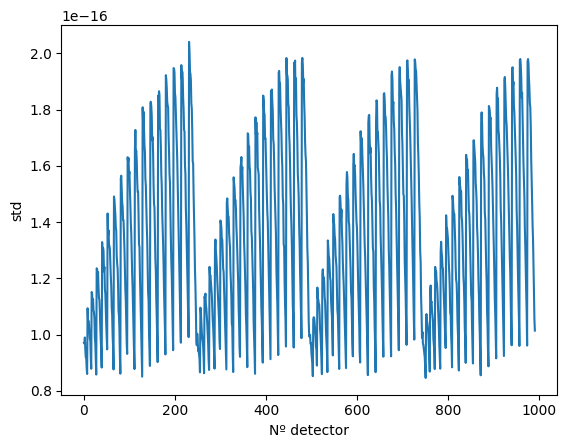

In [22]:
plt.plot(np.std(nn[992:]*np.sqrt(2)/fact, axis=1))
plt.xlabel('Nº detector')
plt.ylabel('std')
plt.show()

Text(0, 0.5, 'std')

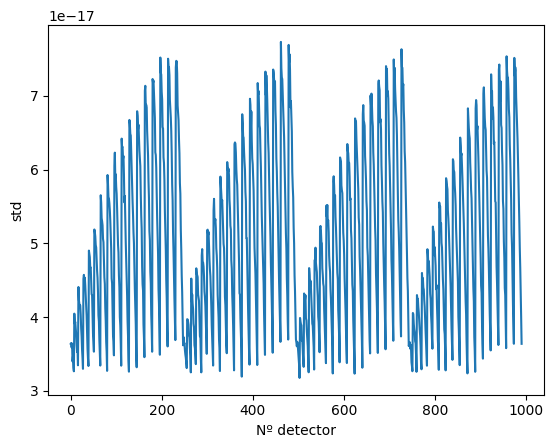

In [23]:
plt.plot(np.std(nn[:992]*np.sqrt(2)/fact, axis=1))
plt.xlabel('Nº detector')
plt.ylabel('std')

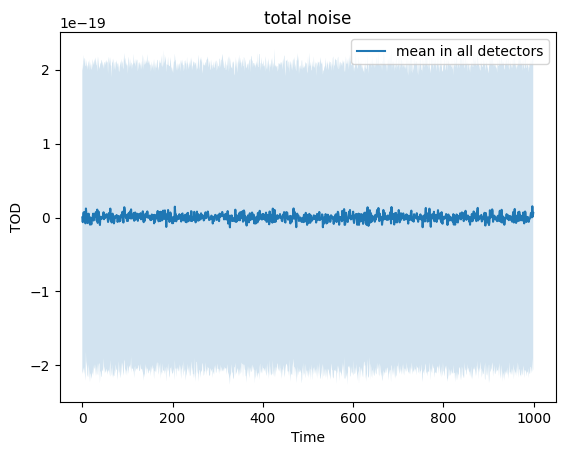

In [34]:
#plt.plot(nn[0], label='noise 1 detector')
plt.plot(samp, np.mean(nn, axis=0), label='mean in all detectors')
plt.fill_between(samp, y1 = np.mean(nn, axis=0) - np.std(nn, axis=0), y2 = np.mean(nn, axis=0) + np.std(nn, axis=0), alpha=0.2)
plt.legend()
plt.title('total noise')
plt.xlabel('Time')
plt.ylabel('TOD')
plt.show()

In [13]:
np.shape(nn)  # number of detectors, number of samplings

(1984, 1000)

In [16]:
dict_out

{'debug': False,
 'config': 'TD',
 'filter_nu': 220000000000.0,
 'filter_relative_bandwidth': 0.25,
 'beam_shape': 'gaussian',
 'MultiBand': True,
 'nf_sub': 8,
 'center_detector': False,
 'psd': None,
 'bandwidth': None,
 'twosided': None,
 'sigma': None,
 'detector_nep': 4.7e-17,
 'detector_fknee': 0,
 'detector_fslope': 1,
 'detector_ncorr': 10,
 'detector_ngrids': 1,
 'detector_tau': 0.01,
 'polarizer': True,
 'synthbeam_fraction': 1,
 'synthbeam_kmax': 1,
 'synthbeam_peak150_fwhm': 0.39268176,
 'ripples': False,
 'nripples': 0,
 'focal_length': 0.3,
 'optics': 'CalQubic_Optics_v3_CC_FFF.txt',
 'primbeam': 'CalQubic_PrimBeam_v2.fits',
 'detarray': 'CalQubic_DetArray_v4_CC.fits',
 'hornarray': 'CalQubic_HornArray_CC.fits',
 'synthbeam': 'CalQubic_Synthbeam_Analytical_220_FI.fits',
 'nside': 128,
 'kind': 'IQU',
 'absolute': False,
 'temperature': 2.7255,
 'summer': False,
 'RA_center': 0,
 'DEC_center': -57,
 'period': 1,
 'date_obs': '2016-01-01 00:00:00',
 'latitude': -24.18333333

In [32]:
from qubic.lib.Instrument.Qinstrument import QubicInstrument

In [35]:
acq = QubicAcquisition(QubicInstrument(dict_out), joint.qubic.sampling, joint.qubic.scene, dict_out)
inst = QubicInstrument(dict_out)
pho_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=False, photon_noise=True)
det_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=True, photon_noise=False)
total_noise = inst.get_noise(joint.qubic.sampling, joint.qubic.scene, det_noise=True, photon_noise=True)

In [34]:
np.shape(det_noise)

(992, 1000)

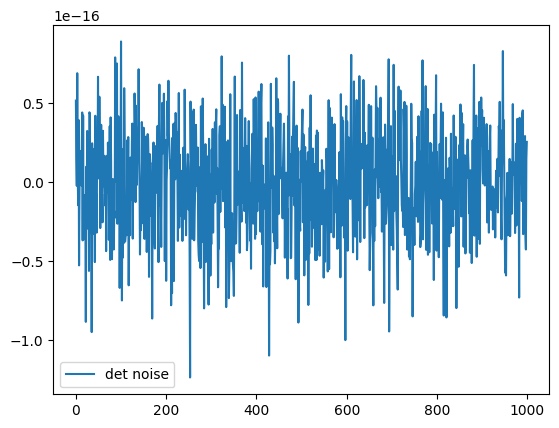

In [16]:
plt.plot(det_noise[0], label='det noise')
plt.legend()

In [26]:
# de instrument sacamos el NEP del photon noise, en pysimulators hace la realizacion de ruido

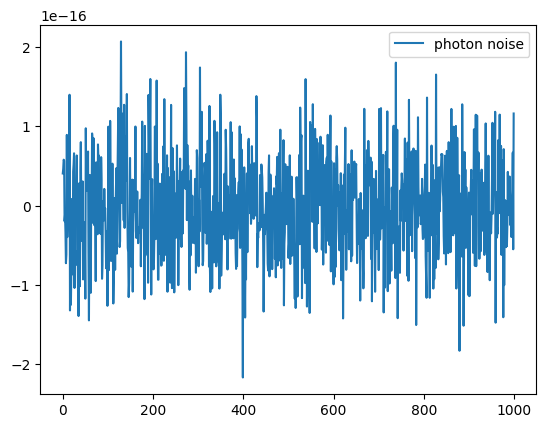

In [35]:
plt.plot(pho_noise[0], label='photon noise')
plt.legend()

Text(0, 0.5, 'NEP')

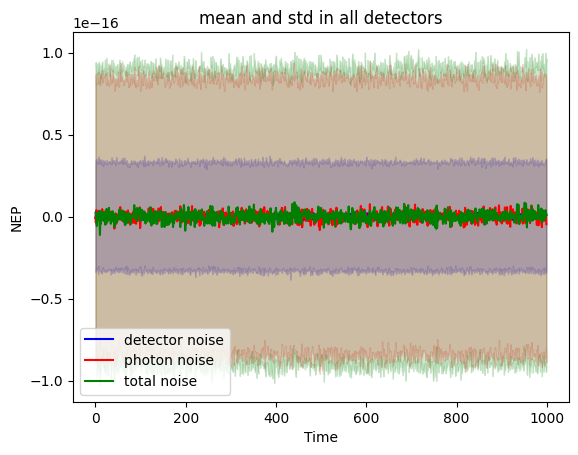

In [40]:
plt.plot(samp, np.mean(det_noise, axis=0), color='blue', label='detector noise')
plt.fill_between(samp, y1 = np.mean(det_noise, axis=0) - np.std(det_noise, axis=0), y2 = np.mean(det_noise, axis=0) + np.std(det_noise, axis=0), color='blue', alpha=0.2)

plt.plot(samp, np.mean(pho_noise, axis=0), color='red', label='photon noise')
plt.fill_between(samp, y1 = np.mean(pho_noise, axis=0) - np.std(pho_noise, axis=0), y2 = np.mean(pho_noise, axis=0) + np.std(pho_noise, axis=0), color='red', alpha=0.2)

plt.plot(samp, np.mean(total_noise, axis=0), color='green', label='total noise')
plt.fill_between(samp, y1 = np.mean(total_noise, axis=0) - np.std(total_noise, axis=0), y2 = np.mean(total_noise, axis=0) + np.std(total_noise, axis=0), color='green',  alpha=0.2)


plt.legend()
plt.title('mean and std in all detectors')
plt.xlabel('Time')
plt.ylabel('NEP')

Text(0, 0.5, 'NEP')

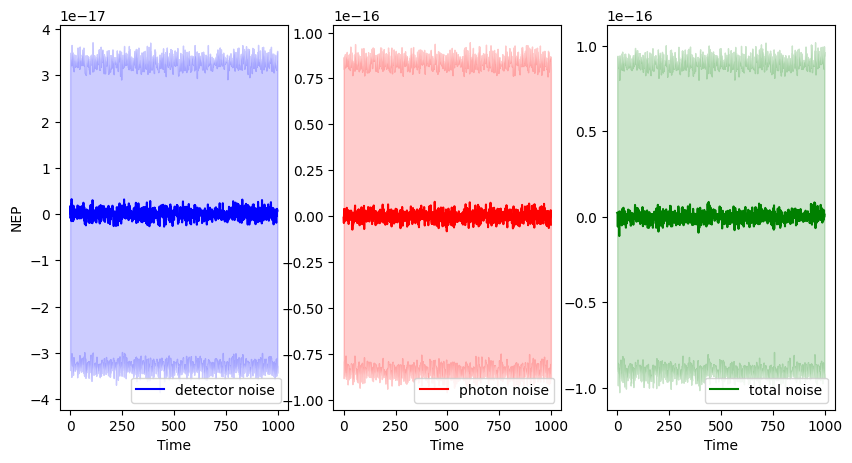

In [43]:
fig, ax  = plt.subplots(1, 3, figsize=(10,5))

ax[0].plot(samp, np.mean(det_noise, axis=0), color='blue', label='detector noise')
ax[0].fill_between(samp, y1 = np.mean(det_noise, axis=0) - np.std(det_noise, axis=0), y2 = np.mean(det_noise, axis=0) + np.std(det_noise, axis=0), color='blue', alpha=0.2)
ax[0].legend()

ax[1].plot(samp, np.mean(pho_noise, axis=0), color='red', label='photon noise')
ax[1].fill_between(samp, y1 = np.mean(pho_noise, axis=0) - np.std(pho_noise, axis=0), y2 = np.mean(pho_noise, axis=0) + np.std(pho_noise, axis=0), color='red', alpha=0.2)
ax[1].legend()

ax[2].plot(samp, np.mean(total_noise, axis=0), color='green', label='total noise')
ax[2].fill_between(samp, y1 = np.mean(total_noise, axis=0) - np.std(total_noise, axis=0), y2 = np.mean(total_noise, axis=0) + np.std(total_noise, axis=0), color='green',  alpha=0.2)
ax[2].legend()


#plt.title('mean and std in all detectors')
ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[2].set_xlabel('Time')

ax[0].set_ylabel('NEP')

In [45]:
np.std(total_noise)

9.115830081712818e-17

In [50]:
np.shape(np.mean(total_noise, axis=1)) # media por detector

(992,)

Text(0.5, 1.0, 'Histogram of NEP values in each detector')

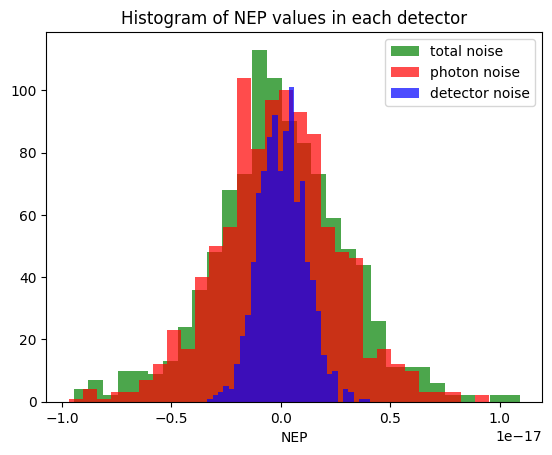

In [54]:
plt.hist(np.mean(total_noise, axis=1), bins=30, color='green', alpha = 0.7, label='total noise' )
plt.hist(np.mean(pho_noise, axis=1), bins=30, color='red', alpha = 0.7, label='photon noise')
plt.hist(np.mean(det_noise, axis=1), bins=30, color='blue', alpha = 0.7, label='detector noise' )
plt.xlabel('NEP')
plt.legend()
plt.title('Histogram of NEP values in each detector')

In [15]:
sampling = joint.qubic.sampling
ns = sampling.comm.allreduce(len(sampling))
ns # nro de pointings

3000

In [25]:
# el factor que multiplica debe ser algo en como hace los TOD en FMM

In [24]:
pho_noise_fact = pho_noise*np.sqrt(ns * sampling.period / (4 * 31557600))

In [27]:
# voy a intentar ver cada componenente

In [32]:
#qinstrument = qubic.QubicMultibandInstrument(dict_out) # esto entiendo que es software viejo y ya yo no lo podemos hacer
# scene = qubic.QubicScene(dict)
# noisepar = qinstrument[0].load_NEP_parameters(scene)

In [33]:
# it computes the total NEP as sqrt{sum_i NEP_phot2_i + NEP_env2}

In [ ]:
# crea un objeto en el que carga atributos fisicos y opticos 

In [52]:
noisepar = inst.load_NEP_parameters(joint.qubic.scene)

In [53]:
noisepar.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'9cmlpe',
 b'11cmlpe',
 b'bdf']

In [55]:
scene = joint.qubic.scene

In [58]:
#T_atm = scene.atmosphere.temperature
#tr_atm = scene.atmosphere.transmission
#em_atm = scene.atmosphere.emissivity
#T_cmb = scene.temperature

In [60]:
# los parametros de CMB y atmosfera estan en dict_out, pero los de otros componentes en una parte llamada optics (cc)

In [56]:
noisepar.temperatures # Temperatura de CMB, atm y de los componentes opticos (los que figuran arriba)
# se hace lo mismo para las transmisiones (fraccion de señal que pasa sin ser absorbida, 0 no pasa nada, 1 pasa todo)
# emisividades (Fracción de energía que el cuerpo emite como radiación térmica)
# estado de polarizacion (cuántos estados de polarización independientes tiene cada componente)

array([  2.7255, 270.    , 290.    , 290.    , 290.    ,  45.    ,
        45.    ,  45.    ,   5.    ,   5.    ,   5.    ,   5.    ,
         5.    ,   1.    ,   1.    ,   1.    ,   1.    ,   0.35  ,
         0.35  ,   0.35  ])

In [55]:
# no polarizado (CMB y atmósfera se consideran no polarizados para el cálculo de ruido de fotones)
# cc["nstates_pol"] → número de estados de polarización de cada componente óptico (por ejemplo, un polarizador tendría 1 estado polarizado, un espejo puede reflejar dos estados, etc.)

In [57]:
noisepar.transmissions 

array([1.  , 1.  , 0.98, 0.98, 0.98, 0.95, 0.98, 0.98, 0.98, 0.95, 0.95,
       0.99, 0.99, 0.99, 0.95, 0.95, 1.  , 0.98, 0.98, 0.98])

In [61]:
# componentes: 

# 1. Compute the noise of the components before the horn array 
# 2. luego el horn 
# 3. NEP environment
# 4. Combiner 
# 5. cold stop low pass edge
# 6. dicroico para el full instrument 
# 7. neutral density filter (no entiendo bien)
# 8. The two before last low pass Edge
# 9. 

In [64]:
noise.ib2b

12

In [78]:
noise.nu/1e9

220.0

In [79]:
noise.dnu/1e9

55.0

In [60]:
noisepar.nu # FI, central density? 

220000000000.0

In [61]:
# return only true te devuelve solo esa componente

In [68]:
dict_before_horns = inst.NEP_before_horns(noisepar, noisepar.nu, return_only=True, sampling=sampling) # se reescriben los 12 primeros NEP para cada detector
# 150 band
dict_horns = inst.NEP_horns(noisepar, return_only=True, sampling=sampling)
dict_env = inst.NEP_environment(noisepar, noisepar.names, return_only=True, sampling=sampling)
dict_combiner = inst.NEP_combiner(noisepar, return_only=True, sampling=sampling)
dict_coldspot = inst.NEP_coldstop(noisepar, return_only=True, sampling=sampling)

dict_lowpass1 = inst.NEP_lowpassedge(noisepar, noisepar.lpe1, return_only=True, sampling=sampling)

dict_lowpass2 = inst.NEP_lowpassedge(noisepar, noisepar.lpe2, return_only=True, sampling=sampling)

dict_last = inst.NEP_lastfilter(noisepar, return_only=True, sampling=sampling)

In [91]:
noisepar.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'9cmlpe',
 b'11cmlpe',
 b'bdf']

In [86]:
allnoisearray = [dict_before_horns, dict_horns, dict_combiner, dict_coldspot, dict_lowpass1, dict_lowpass2]

In [71]:
np.shape(dict_before_horns['power']) # P_phot

(12, 992)

In [89]:
ncomp_before_horns = len(dict_before_horns["power"])
ncomp_after_horns = len(allnoisearray[1:])

In [79]:
np.shape(inst.detector.center.T[1])

(992,)

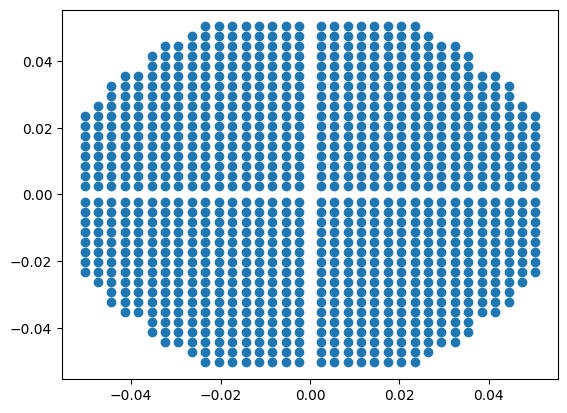

In [80]:
plt.scatter(inst.detector.center.T[0], inst.detector.center.T[1])

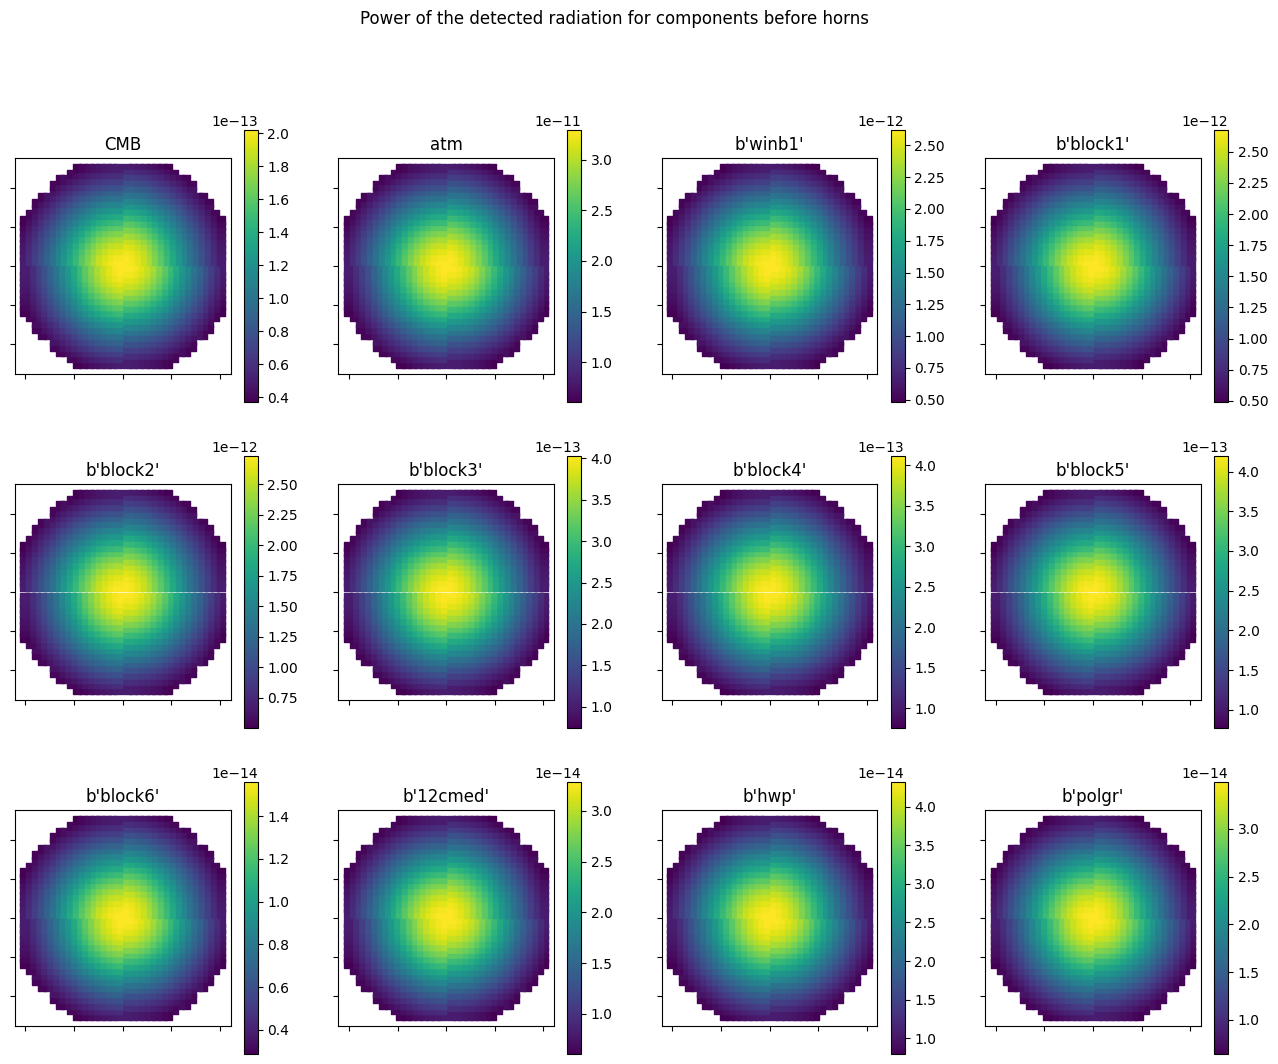

In [88]:
fig2, ax2 = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))
fig2.suptitle('Power of the detected radiation for components before horns')
ax2 = ax2.ravel()
for j in range(ncomp_before_horns):
    ax2[j].cla()
    plt.axes(ax2[j])
    ax2[j].set_title("{}".format(noisepar.names[j]))
    cp = ax2[j].scatter(inst.detector.center.T[0],
                        inst.detector.center.T[1],
                        c = allnoisearray[0]['power'][j], marker = 's')
    cbar = fig2.colorbar(cp,)
    ax2[j].set_xticklabels("")
    ax2[j].set_yticklabels("")
    ax2[j].set_aspect('equal')
    
plt.savefig('power_focalplane_components.png')

In [85]:
noisepar.names

['CMB',
 'atm',
 b'winb1',
 b'block1',
 b'block2',
 b'block3',
 b'block4',
 b'block5',
 b'block6',
 b'12cmed',
 b'hwp',
 b'polgr',
 b'ba2ba',
 b'combin',
 b'cslpe',
 b'dichro',
 b'ndf',
 b'9cmlpe',
 b'11cmlpe',
 b'bdf']

In [96]:
# ver bien este directorio y la relacion con los parametros del YALM que no entiendo bien que incluye FI y
# el tema de las bandas

# en el FI creo que tenes en total 2 x 992 detectores, o sea cada banda tiene 992, pero si puse una unica banda
# de donde se lee el diccionario? por qué filter_nu es 220 

In [93]:
dict_out

{'debug': False,
 'config': 'FI',
 'filter_nu': 220000000000.0,
 'filter_relative_bandwidth': 0.25,
 'beam_shape': 'gaussian',
 'MultiBand': True,
 'nf_sub': 8,
 'center_detector': False,
 'psd': None,
 'bandwidth': None,
 'twosided': None,
 'sigma': None,
 'detector_nep': 4.7e-17,
 'detector_fknee': 0,
 'detector_fslope': 1,
 'detector_ncorr': 10,
 'detector_ngrids': 1,
 'detector_tau': 0.01,
 'polarizer': True,
 'synthbeam_fraction': 1,
 'synthbeam_kmax': 1,
 'synthbeam_peak150_fwhm': 0.39268176,
 'ripples': False,
 'nripples': 0,
 'focal_length': 0.3,
 'optics': 'CalQubic_Optics_v3_FI_220.txt',
 'primbeam': 'CalQubic_PrimBeam_v2.fits',
 'detarray': 'CalQubic_DetArray_v4_FI.fits',
 'hornarray': 'CalQubic_HornArray_FI.fits',
 'synthbeam': 'CalQubic_Synthbeam_Analytical_220_FI.fits',
 'nside': 256,
 'kind': 'IQU',
 'absolute': False,
 'temperature': 2.7255,
 'summer': False,
 'RA_center': 0,
 'DEC_center': -57,
 'period': 1,
 'date_obs': '2016-01-01 00:00:00',
 'latitude': -24.18333333

In [92]:
# esta corrrespondecnia con los nombres debe estar mal

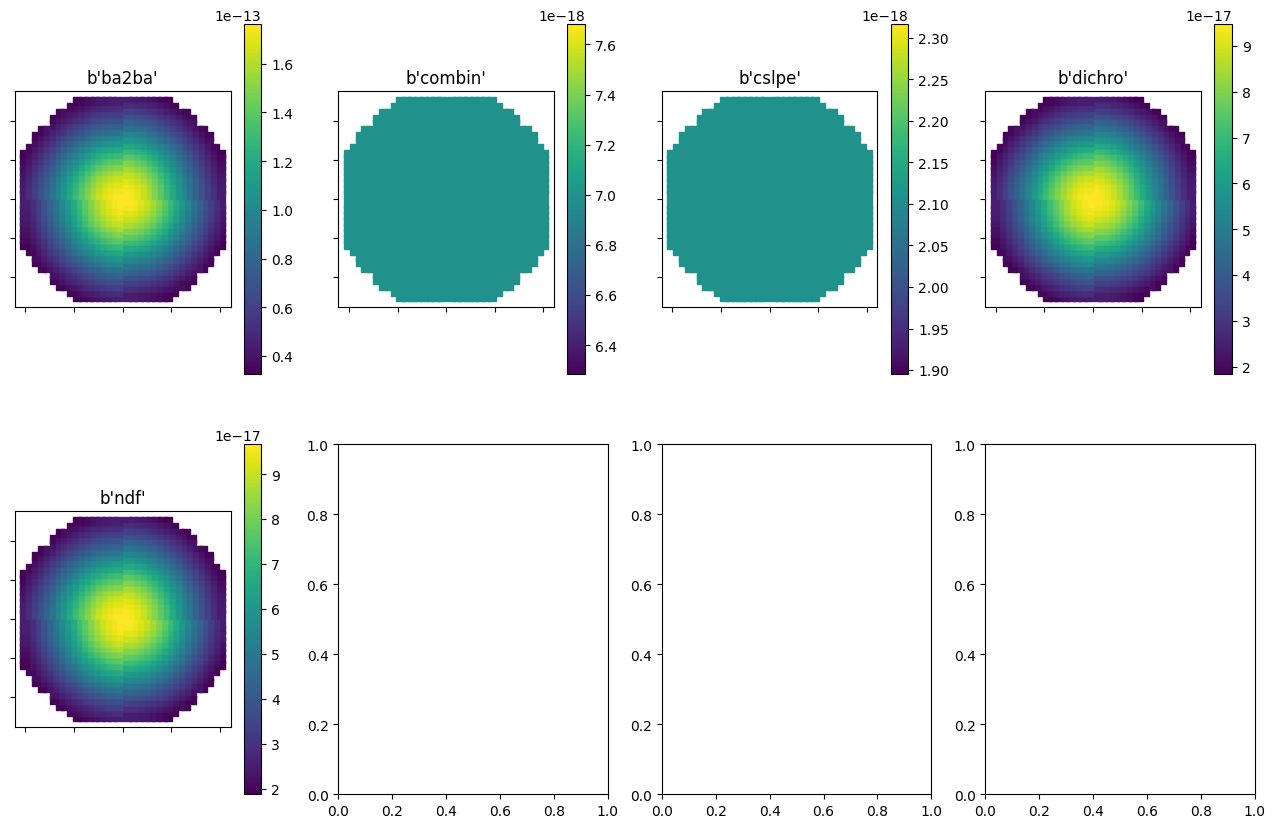

In [90]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (16,10))
ax = ax.ravel()
for i in range(0,ncomp_after_horns):
    ax[i].cla()
    plt.axes(ax[i])
    ax[i].set_title("{}".format(noisepar.names[i + ncomp_before_horns]))
    cp = ax[i].scatter(inst.detector.center.T[0],inst.detector.center.T[1],c = allnoisearray[i+1]['power'], marker = 's')
    cbar = fig.colorbar(cp,)
    ax[i].set_xticklabels("")
    ax[i].set_yticklabels("")
    ax[i].set_aspect('equal')

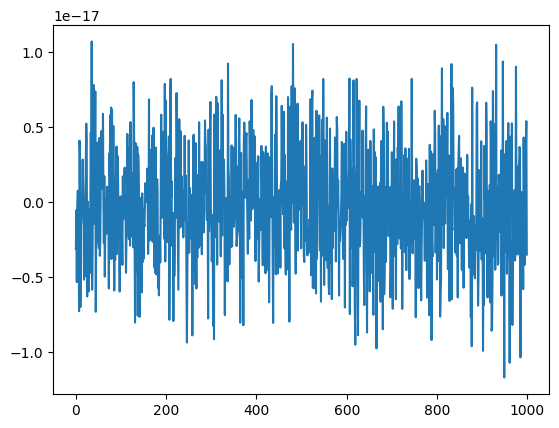

In [86]:
plt.plot(dict['NEP_array'][0][0])

In [67]:
np.shape(noise.P_phot) 

(20, 992)

In [71]:
noise.P_phot[:12] # 12 primeros P_phot

array([[4.98868996e-14, 4.92583347e-14, 4.81660976e-14, ...,
        6.79851067e-14, 5.85046095e-14, 4.98868996e-14],
       [8.13603784e-12, 8.03352540e-12, 7.85539280e-12, ...,
        1.10876684e-11, 9.54149726e-12, 8.13603784e-12],
       [6.47040312e-13, 6.38887734e-13, 6.24721260e-13, ...,
        8.81776679e-13, 7.58813257e-13, 6.47040312e-13],
       ...,
       [8.09943445e-15, 7.99738320e-15, 7.82005201e-15, ...,
        1.10377859e-14, 9.49857082e-15, 8.09943445e-15],
       [1.06571506e-14, 1.05228726e-14, 1.02895421e-14, ...,
        1.45234024e-14, 1.24981195e-14, 1.06571506e-14],
       [8.61183886e-15, 8.50333142e-15, 8.31478151e-15, ...,
        1.17360828e-14, 1.00994905e-14, 8.61183886e-15]])

In [76]:
np.shape(noise.NEP_phot2[0]) # NEP del primer componente de los 12 para los 992 detectores

(992,)